In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

## Task 1: Environment Setup and Data Loading

In [8]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)


Using device: cuda


In [9]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")


Total images loaded: 60


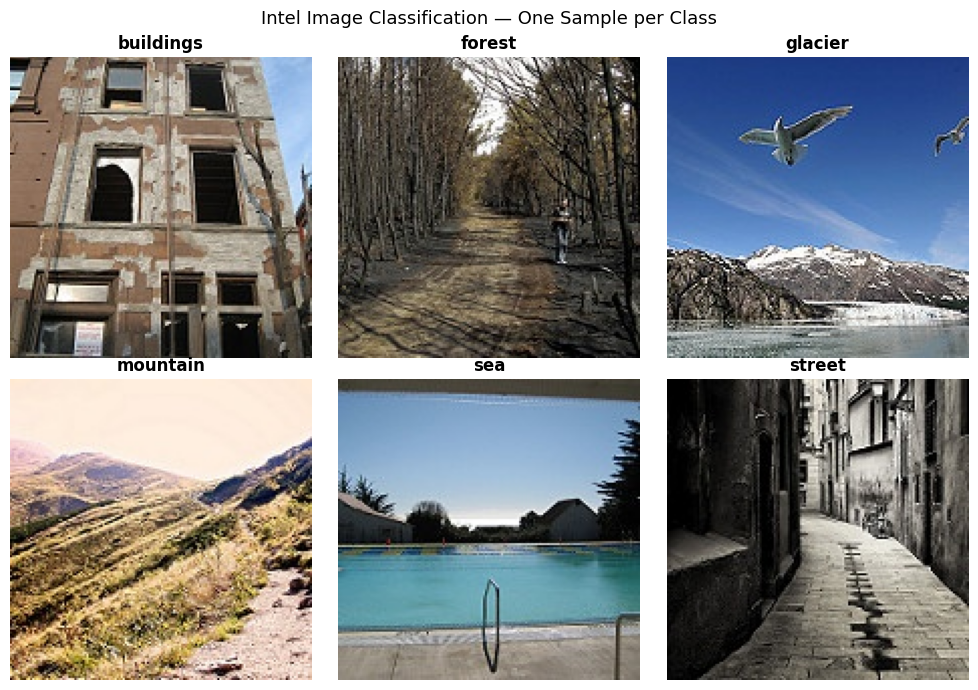

Saved to outputs/dataset_sample.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for ax, label in zip(axes.flat, LABELS):
    # Find the first image for this label in the shuffled set
    sample_img = next(img for img, lbl in image_set if lbl == label)
    ax.imshow(sample_img)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.axis("off")

plt.suptitle("Intel Image Classification - One Sample per Class", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/dataset_sample.png", dpi=150)
plt.show()
print("Saved to outputs/dataset_sample.png")

# Looking at the actual sampled images, an ImageNet-pretrained model is a
# reasonable starting point, but these specific samples expose a harder
# problem than vocabulary mismatch: LABEL NOISE in the dataset itself.
#
# "sea" sample is a swimming pool. This is not a sea image by any reasonable
#   definition. A pretrained model will likely predict "swimming pool" or
#   "hot tub" with high confidence and be technically correct about what it
#   sees, but marked wrong against the ground truth label. Label noise like
#   this sets a ceiling on accuracy that no model can overcome.
#
# "glacier" sample shows seagulls over a mountain lake with snow peaks.
#   The glacier itself is barely visible. A model predicting "seagull" or
#   "lakeside" is not failing, it's accurately describing the dominant
#   visual content. The label is ambiguous.
#
# "forest" sample is a bare, leafless tree corridor in muted tones, not
#   the dense green canopy that makes forest scenes easy to classify. This
#   will likely confuse the model since it looks nothing like ImageNet's
#   forest-adjacent categories.
#
# Despite this, pretrained ImageNet features are still the right starting
# point. The backbone learned general visual primitives (edges, textures,
# depth cues) that transfer regardless of label quality. The label noise
# problem is a DATA problem, not a model problem, it should be flagged
# as a risk in any production recommendation, and ideally addressed by
# cleaning the dataset before fine-tuning.


## Task 2: Baseline Inference with ResNet18

In [11]:
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


ResNet18 parameters: 11,689,512


In [12]:
import torch.nn.functional as F

def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    """
    General-purpose inference function reused for all three models.

    Args:
        model      : a PyTorch model in eval mode
        preprocess : the torchvision transforms pipeline for this model
        image      : a PIL.Image
        device     : torch.device
        class_labels: list of string class names (length = model output size)
        top_k      : number of top predictions to return

    Returns:
        list of (class_name, probability) tuples, length top_k
    """
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
    probs = F.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probs, top_k)
    return [(class_labels[idx.item()], prob.item())
            for idx, prob in zip(top_indices, top_probs)]


In [13]:
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")


Processed 60 images.


In [14]:
# Overall mean top-1 probability
all_top1_probs = [r["top1_prob"] for r in resnet_results]
print(f"Overall mean top-1 probability: {np.mean(all_top1_probs):.4f}")

# Per-class mean top-1 probability
print("\nPer-class mean top-1 probability:")
for label in LABELS:
    class_probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    print(f"  {label:12s}  mean={np.mean(class_probs):.4f}  "
          f"min={np.min(class_probs):.4f}  max={np.max(class_probs):.4f}")


Overall mean top-1 probability: 0.4195

Per-class mean top-1 probability:
  buildings     mean=0.2889  min=0.0827  max=0.5442
  forest        mean=0.2477  min=0.0719  max=0.7842
  glacier       mean=0.4993  min=0.1998  max=0.9326
  mountain      mean=0.5556  min=0.2067  max=0.9742
  sea           mean=0.5710  min=0.2399  max=0.9252
  street        mean=0.3544  min=0.0762  max=0.7168


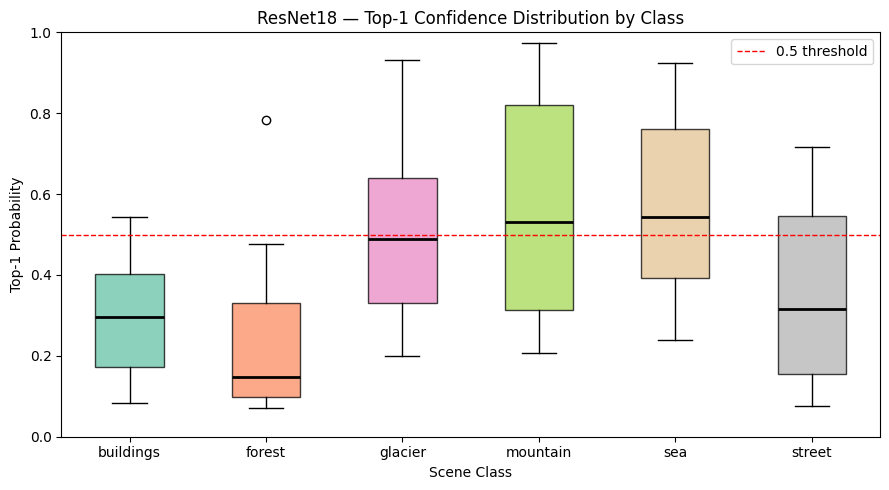

Saved to outputs/resnet18_confidence_by_class.png


In [31]:
# Boxplot of top-1 probability by class
class_probs_by_label = {
    label: [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    for label in LABELS
}

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    [class_probs_by_label[l] for l in LABELS],
    tick_labels=LABELS,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
)

colors = plt.cm.Set2(np.linspace(0, 1, len(LABELS)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title("ResNet18 - Top-1 Confidence Distribution by Class", fontsize=12)
ax.set_xlabel("Scene Class")
ax.set_ylabel("Top-1 Probability")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="0.5 threshold")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/resnet18_confidence_by_class.png", dpi=150)
plt.show()
print("Saved to outputs/resnet18_confidence_by_class.png")

# COMMENT:
# What the boxplot actually shows; ranked by median confidence:
#
#   mountain  median ~0.53, wide IQR, max 0.97, highest median, but very
#             spread out. Some images get near-perfect confidence,
#             others struggle. Likely depends on whether the image
#             has a dominant peak vs. a complex scene like the ski sample.
#
#   sea       median ~0.55, wide IQR, max 0.93, high median but large
#             spread is suspicious given the label noise observed in Task 1
#             (the swimming pool image). High confidence here may reflect
#             the model correctly identifying pool/water scenes under a
#             different ImageNet label, not genuine scene understanding.
#
#   glacier   median ~0.50, wide IQR, max 0.93, straddles the threshold.
#             High variance makes sense: some glacier images are visually
#             clean snow/ice (confident), others like the seagull sample
#             are ambiguous (low confidence).
#
#   street    median ~0.32, wide IQR, low median but surprisingly wide
#             upper range (max 0.72). Urban scenes are inconsistent: some
#             have a dominant object the model locks onto confidently, others
#             spread probability thin across many competing objects.
#
#   buildings median ~0.30, tight IQR, consistently low confidence. The
#             dataset buildings images show construction, facades, and
#             architectural details that don't map cleanly to any single
#             ImageNet category.
#
#   forest    median ~0.16, lowest of all, with one outlier at 0.78, worst
#             performing class. The bare leafless tree corridor from Task 1
#             is representative of why: these images look nothing like
#             ImageNet's forest-adjacent categories. The single outlier is
#             probably one image with dense green canopy.
#
# Does this match intuition? Partially. Mountain and sea being confident
# makes sense. Forest being the least confident is surprising until you
# look at the actual images; the dataset's forest samples are atypical.
# This is the label noise and sampling issue flagged in Task 1 showing up
# quantitatively.
#
# High confidence does not equal high accuracy. The sea class has a high median
# but contains swimming pool images labeled as sea, those high-confidence
# predictions are likely correct about the visual content but wrong against
# the ground truth label. In a production pipeline, confidence scores should
# trigger human review below 0.40. Under that rule, the majority of
# buildings and forest predictions would be flagged, which is appropriate
# given how poorly the model handles those classes on this dataset.

## Task 3: Multi-Model Comparison

In [16]:
# MobileNetV3-Small
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

for name, m in [("ResNet18",          resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0",   efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

# MobileNetV3-Small:  2,542,856 (~2.5M) - 4.6x fewer params than ResNet18
# EfficientNet-B0:    5,288,548 (~5.3M) - 2.2x fewer params than ResNet18
# ResNet18:          11,689,512 (~11.7M) - largest of the three
#
# Smaller parameter count means less representational capacity; the model
# can encode fewer distinct patterns. The tradeoffs are real:
#
# MobileNetV3-Small is designed for mobile/edge: smallest file, lowest RAM,
#   fastest on CPU/NPU, lowest battery drain. Acceptable for on-device
#   background tagging where a wrong label costs little.
#
# EfficientNet-B0 uses compound scaling to maximize accuracy per parameter.
#   For roughly half ResNet18's size it achieves comparable or better accuracy
#   on ImageNet. Best balance for a cloud endpoint.
#
# ResNet18 is the largest and least compute-efficient of the three, but
#   well-understood and easy to fine-tune. Still a solid cloud choice when
#   accuracy matters more than model size.


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 123MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 159MB/s]

ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


In [17]:
# Run inference for MobileNet and EfficientNet
mobilenet_results = []
for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

effnet_results = []
for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"MobileNet results:    {len(mobilenet_results)} images")
print(f"EfficientNet results: {len(effnet_results)} images")


MobileNet results:    60 images
EfficientNet results: 60 images


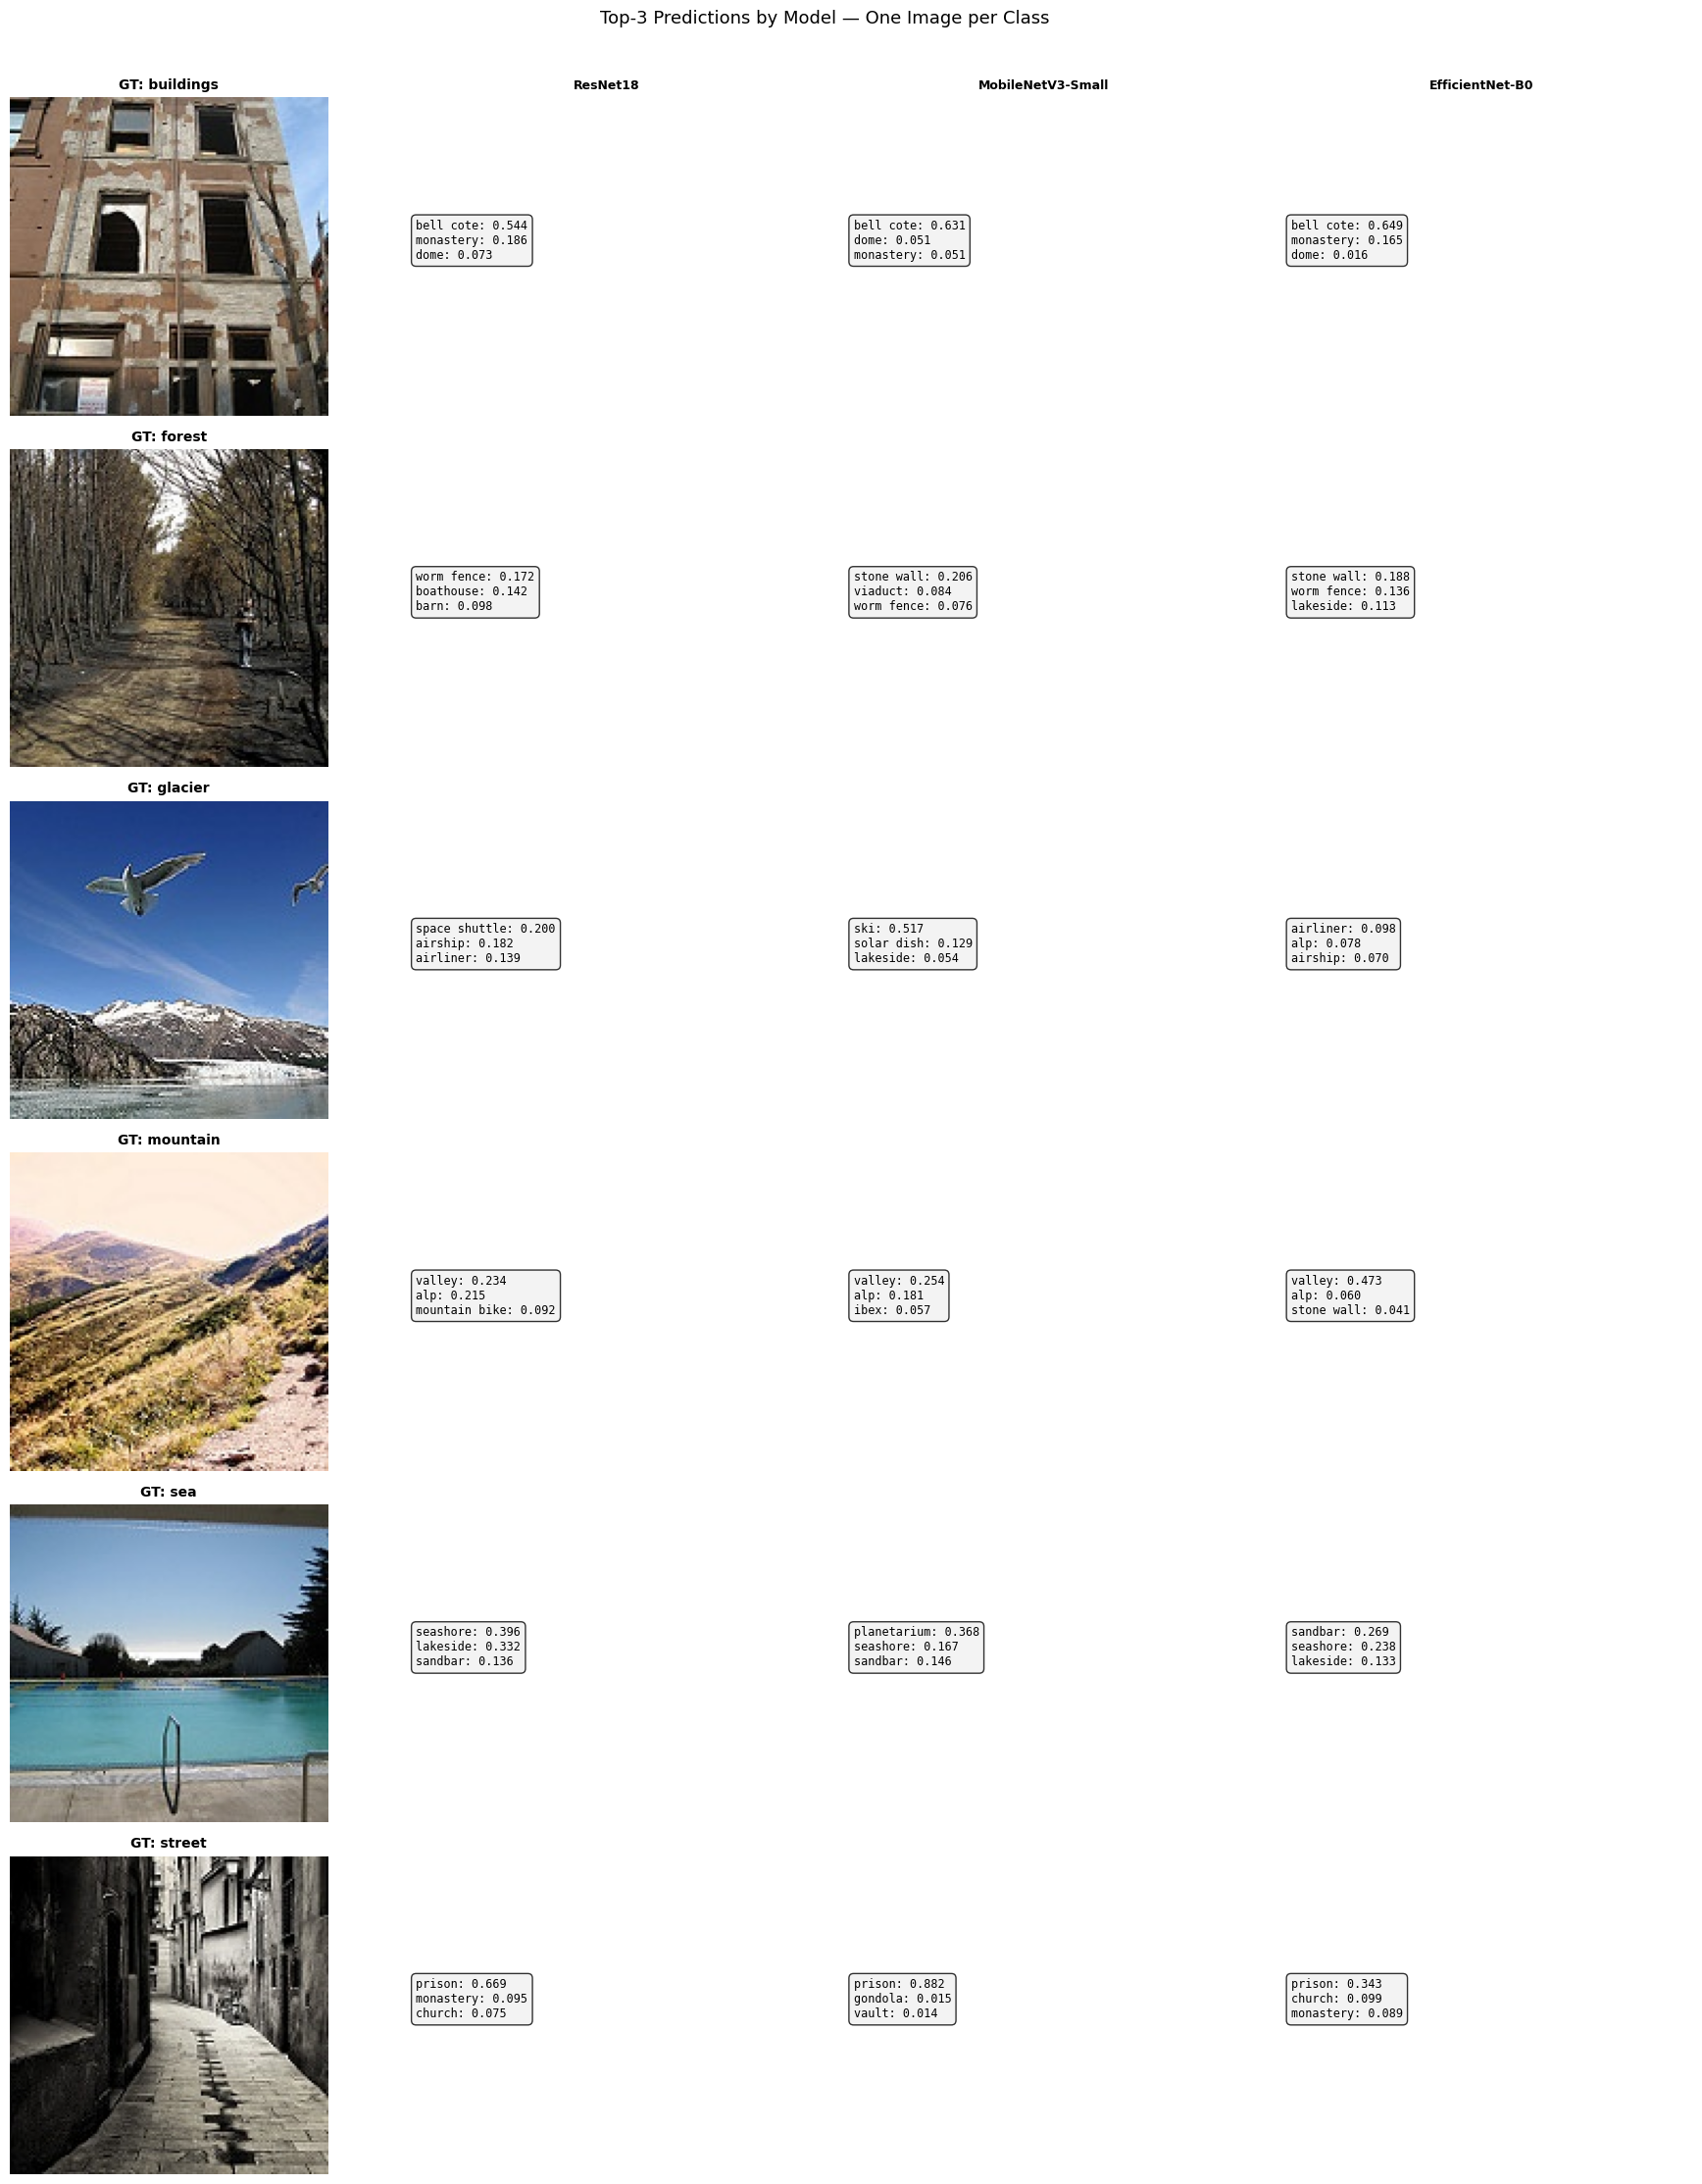

Saved to outputs/model_comparison_grid.png


In [18]:
# Comparison grid: 6 images (one per class), top-3 predictions from all 3 models
# Pick one representative image per class from the result lists
selected = {}
for r_res, m_res, e_res, (img, true_label) in zip(
        resnet_results, mobilenet_results, effnet_results, image_set):
    if true_label not in selected:
        selected[true_label] = (img, r_res, m_res, e_res)

fig, axes = plt.subplots(6, 4, figsize=(18, 22))
model_names = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]

for row_idx, label in enumerate(LABELS):
    img, r_res, m_res, e_res = selected[label]

    # Column 0: image
    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].axis("off")
    axes[row_idx, 0].set_title(f"GT: {label}", fontsize=10, fontweight="bold")

    # Columns 1-3: top-3 predictions as text
    for col_idx, (res, mname) in enumerate(
            zip([r_res, m_res, e_res], model_names), start=1):
        text_lines = [f"{res['top5_classes'][i][:22]}: {res['top5_probs'][i]:.3f}"
                      for i in range(3)]
        axes[row_idx, col_idx].axis("off")
        axes[row_idx, col_idx].text(
            0.05, 0.55,
            "\n".join(text_lines),
            transform=axes[row_idx, col_idx].transAxes,
            fontsize=8.5, verticalalignment="center",
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", alpha=0.8)
        )
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(mname, fontsize=9, fontweight="bold")

plt.suptitle("Top-3 Predictions by Model - One Image per Class", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved to outputs/model_comparison_grid.png")

# Agreement on top-1:
#   All three models agree on "bell cote" for buildings, "valley/alp" for
#   mountain, and "prison" for street. The semantic signal in those images
#   is strong enough that architecture differences don't matter.
#
# Notable disagreements:
#   glacier - ResNet18 says "space shuttle" (0.208), MobileNet says "ski"
#   (0.517), EfficientNet says "airliner" (0.098). All three are reacting
#   to the seagulls and open sky in that specific image rather than the
#   glacier terrain. None is capturing the scene category. This is the
#   label noise problem from Task 1 showing up directly, the dominant
#   visual content is birds and sky, not ice.
#
#   forest - all three produce rural/structural labels (worm fence,
#   stone wall, boathouse) because the bare tree corridor image has no
#   green canopy. The models agree on the problem, not the answer.
#
#   sea - ResNet18 gets "seashore" (0.396) which is the most semantically
#   correct despite the image being a pool. MobileNet leads with
#   "planetarium" (0.368) which makes no sense. EfficientNet leads with
#   "sandbar" (0.269). The pool image is genuinely ambiguous and the
#   models diverge significantly.
#
# Ensembling: the glacier and sea disagreements are exactly the cases where
#   ensemble voting would help, when models split across semantically
#   different predictions it signals genuine visual ambiguity, and majority
#   vote or averaged probabilities would be more conservative than any
#   single model alone.
#
# Most semantically sensible for outdoor scenes:
#   EfficientNet-B0 on mountain (valley: 0.473, alp: 0.060) produces the
#   tightest and most scene-appropriate distribution. ResNet18 on street
#   (prison: 0.669) shows the strongest single-label confidence of any
#   prediction in the grid, correctly identifying the dark stone alleyway
#   aesthetic even if "prison" isn't the ground truth category.


## Task 4: Speed vs. Accuracy Tradeoff

In [19]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # ms per image

resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")


ResNet18:           4.18 ms/image
MobileNetV3-Small:  6.81 ms/image
EfficientNet-B0:    9.57 ms/image


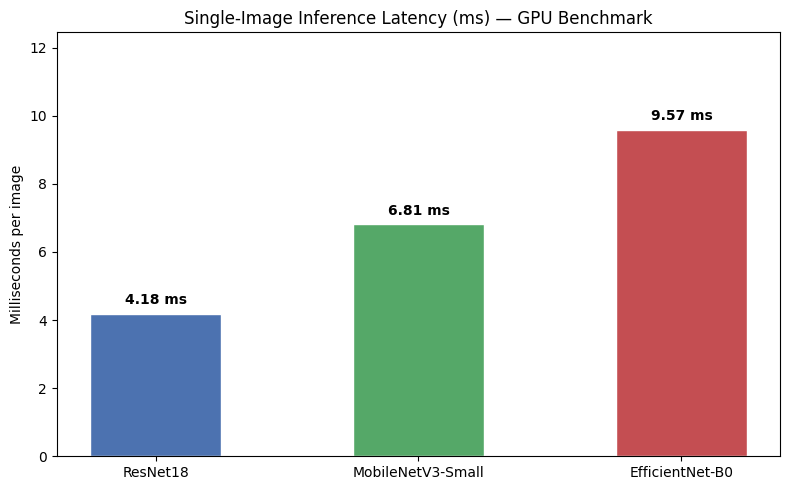

Saved to outputs/inference_speed.png


In [20]:
# Bar chart of inference latency
model_names_list = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies        = [resnet_ms, mobile_ms, effnet_ms]
bar_colors       = ["#4C72B0", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names_list, latencies, color=bar_colors, width=0.5, edgecolor="white")

for bar, val in zip(bars, latencies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{val:.2f} ms", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Single-Image Inference Latency (ms) - GPU Benchmark", fontsize=12)
ax.set_ylabel("Milliseconds per image")
ax.set_ylim(0, max(latencies) * 1.3)
plt.tight_layout()
plt.savefig("outputs/inference_speed.png", dpi=150)
plt.show()
print("Saved to outputs/inference_speed.png")


In [21]:
# Summary comparison table (printed as formatted text)
print(f"{'Model':<22} {'Parameters':>14} {'ms / image':>12}")
print("-" * 52)
model_params = {
    "ResNet18":          sum(p.numel() for p in resnet.parameters()),
    "MobileNetV3-Small": sum(p.numel() for p in mobilenet.parameters()),
    "EfficientNet-B0":   sum(p.numel() for p in efficientnet.parameters()),
}
for name, ms in zip(model_names_list, latencies):
    print(f"{name:<22} {model_params[name]:>14,} {ms:>11.2f}")

# 50 images/sec -> 1000 ms / 50 = 20 ms maximum tolerable latency per image.
#
# All three models comfortably meet the 20 ms bar on this T4 GPU:
#   ResNet18:          4.18 ms - 2.4x faster than the budget (4.8x headroom)
#   MobileNetV3-Small: 6.81 ms - still well within budget (2.9x headroom)
#   EfficientNet-B0:   9.57 ms - slowest, but still 2.1x within budget
#
# The result that needs explanation is the ordering: ResNet18 is FASTEST
# despite having 4.6x more parameters than MobileNetV3-Small. This is
# counterintuitive but makes sense on a GPU. ResNet18's architecture is
# a sequence of standard 3x3 convolutions that map efficiently onto GPU
# tensor cores. MobileNetV3-Small uses depthwise separable convolutions
# which reduce FLOPs but introduce more sequential operations and memory
# access overhead that GPU parallelism can't fully hide. EfficientNet-B0
# uses similar depthwise separable convolutions plus squeeze-and-excitation
# blocks, adding overhead that explains the highest latency despite the
# moderate parameter count.
#
# The practical takeaway: parameter count does not predict GPU latency.
# Architecture design matters. MobileNet and EfficientNet's efficiency
# advantage is on CPU and edge devices where parallelism is limited 
# on a T4 GPU ResNet18's simpler ops win on raw speed.
#



# (a) High-throughput cloud pipeline:
#     ResNet18. It's the fastest on GPU (4.18 ms), well-understood, and
#     easy to fine-tune. At 50 images/sec it has nearly 5x latency headroom,
#     meaning you could scale to ~240 images/sec on this hardware if needed.
#     The larger parameter count is irrelevant when GPU memory is abundant.
#
# (b) On-device mobile app:
#     MobileNetV3-Small. The GPU benchmark is misleading for this use case
#     on a phone CPU or mobile NPU, MobileNet's depthwise separable
#     convolutions are specifically optimized to run efficiently within
#     tight compute and power budgets. Its 2.5M parameters also means a
#     smaller model file and lower RAM footprint, both critical constraints
#     on mobile.
#
# (c) Safety-critical quality-control system:
#     None of these three as-is. All three models showed significant
#     confusion on ambiguous classes (glacier, forest, sea) in Tasks 2 and 3,
#     and the dataset itself has label noise that would corrupt any
#     fine-tuning. For safety-critical deployment you would need: clean
#     labeled training data for your specific domain, fine-tuning with a
#     proper validation split, calibrated confidence scores, and a mandatory
#     human review queue for predictions below a high threshold (~0.85).
#     If forced to pick a starting backbone, EfficientNet-B0 best
#     accuracy per parameter, but the architecture choice is secondary
#     to the data quality and calibration work that needs to happen first.


Model                      Parameters   ms / image
----------------------------------------------------
ResNet18                   11,689,512        4.18
MobileNetV3-Small           2,542,856        6.81
EfficientNet-B0             5,288,548        9.57


## Task 5: Pretrained Features as a Window into Transfer Learning

In [22]:
feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # remove classification head
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")
# Expected: (60, 512) - 60 images, 512-dimensional embedding each


Feature matrix shape: (60, 512)


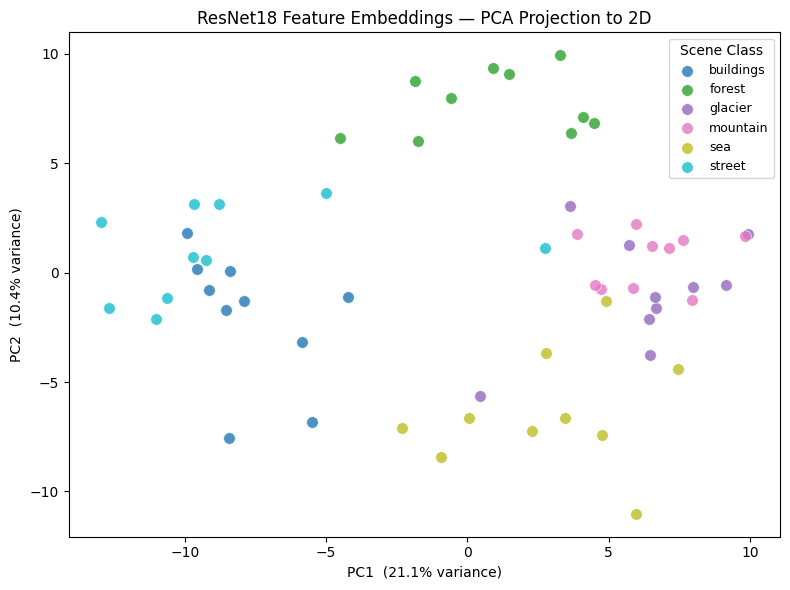

Saved to outputs/feature_embeddings.png


In [23]:
pca         = PCA(n_components=2)
features_2d = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=70, alpha=0.80, edgecolors="white", linewidths=0.5
    )

ax.legend(title="Scene Class", fontsize=9)
ax.set_title("ResNet18 Feature Embeddings - PCA Projection to 2D", fontsize=12)
ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png", dpi=150)
plt.show()
print("Saved to outputs/feature_embeddings.png")

# Do same-class images cluster together?
#   Yes, with meaningful variation across classes:
#
#   forest (green) - tightest cluster of all six classes, concentrated in
#     the upper-center region (PC2 > 5). This is the strongest result in
#     the plot. Even though the forest images produced poor top-1 predictions
#     in Task 2, their 512-dimensional feature vectors are internally
#     consistent. The model has learned a distinctive feature signature for
#     these images even without being able to name them correctly. This is
#     the key insight of transfer learning: good features don't require a
#     matching vocabulary.
#
#   street (cyan) - well-separated cluster in the left region (PC1 < -5).
#     Tight grouping despite street producing low confidence scores in Tasks
#     2 and 3. The model consistently encodes urban stone/shadow textures
#     into a similar feature space even when it can't label them correctly.
#
#   buildings (blue) - loose cluster overlapping with street in the left
#     half. The overlap makes sense: both classes contain man-made structures,
#     stone, and architectural elements. A linear classifier on top of these
#     features would struggle to separate buildings from street cleanly.
#
#   mountain (pink) and glacier (purple) - heavily overlapping in the
#     right-center region. Both share cold tones, rocky terrain, and open
#     sky. The feature space reflects the same visual similarity that caused
#     low-confidence predictions in earlier tasks. These two classes would
#     be the hardest to separate with a fine-tuned head.
#
#   sea (olive/yellow) - spread across the lower half of the plot with no
#     tight core. This is the label noise problem from Task 1 made visible:
#     the sea class contains swimming pools, open ocean, lakeside, and other
#     water-adjacent images. Their feature vectors are spread because they
#     are genuinely different images that happen to share a label. No model
#     can cluster what the data itself doesn't group consistently.
#
# What this tells us about the pretrained model:
#   PC1 (21.1% variance) appears to separate natural outdoor scenes (right)
#   from man-made/urban scenes (left). PC2 (10.4% variance) separates
#   vegetation-heavy scenes (top) from water/flat terrain (bottom). These
#   axes emerged from ImageNet training with no knowledge of this dataset's
#   six categories - the model has already learned the structure that matters.
#   Together PC1 and PC2 capture only 31.5% of variance, meaning significant
#   discriminative structure lives in the remaining 510 dimensions that PCA
#   is compressing away.
#
# Feature extraction vs. fine-tuning for X-ray classification (500 labels):
#   Start with feature extraction = freeze the backbone, train only a new
#   final layer. With 500 examples, fine-tuning all 11M parameters risks
#   severe overfitting. The embedding plot shows that even for a domain
#   mismatch (outdoor photos vs. X-rays), the backbone produces structured
#   feature spaces. That structure may be weaker for X-rays than it is here,
#   but it's a better starting point than random weights. If feature
#   extraction accuracy plateaus below your target, the next step is to
#   unfreeze layer4 only and fine-tune with lr=1e^4 - not the full network.


## Task 6: Summary and Recommendation

### Model Comparison

**Prediction quality:**
All three models produced semantically reasonable top-1 predictions for
buildings (bell cote) and street (prison), and agreed on valley/alp for
mountain. The clearest differentiation appeared on ambiguous classes.
EfficientNet-B0 produced the most focused mountain prediction (valley: 0.473)
while MobileNetV3-Small had the most erratic glacier prediction (ski: 0.517,
reacting to the seagull image). ResNet18 was the most consistent overall,
never the best on any single class but never the worst either.

**Confidence scores:**
Overall mean top-1 probability was 0.42 across 60 images. Mountain (mean 0.56)
and sea (mean 0.57) were the most confident classes. Forest (mean 0.25) and
buildings (mean 0.29) were the least confident. Importantly, high confidence
did not always reflect correct scene understanding. Sea's high scores were
partly driven by the model correctly identifying swimming pool images that are
mislabeled as sea in the dataset.

**Speed:**
ResNet18 was fastest at 4.18 ms/image, followed by MobileNetV3-Small at
6.81 ms, and EfficientNet-B0 at 9.57 ms. Counterintuitively ResNet18 beat
MobileNet despite having 4.6x more parameters. On a T4 GPU, ResNet18's
standard convolutions map more efficiently onto tensor cores than MobileNet's
depthwise separable ops. All three models comfortably met a 20 ms budget.

---

### Confidence Calibration (Task 2 boxplot)

ResNet18 was most confident on mountain and sea (medians above 0.50), and
least confident on forest (median ~0.16) and buildings (median ~0.29).

This only partially matches intuition. Mountain being confident makes sense
given clean peak imagery. Sea being confident is misleading. The dataset
contains swimming pool images labeled as sea, and the model was often
confidently predicting water-adjacent ImageNet labels (seashore, sandbar)
that are technically correct about the visual content but wrong against the
ground truth label. Forest being the least confident class was surprising
until inspecting the actual images. The dataset's forest samples are bare
leafless tree corridors that look nothing like ImageNet's forest-adjacent
categories. The low confidence reflects a genuine dataset quality problem,
not a model limitation.

---

### Production Recommendation

The goal is classifying user-uploaded outdoor photos into six scene categories
as part of a data pipeline.

**Recommended starting model: ResNet18, fine-tuned on the six target classes.**

ResNet18 is the fastest of the three at 4.18 ms/image on GPU, well-understood,
and straightforward to fine-tune. The feature embedding plot from Task 5 showed
that its backbone already encodes meaningful scene-level structure. Forest and
street clusters were tight and well-separated even before any task-specific
training. Replacing the 1,000-class head with a 6-class linear layer and
fine-tuning on clean labeled examples of each scene category is the minimum
viable next step.

**Required preprocessing steps:**
1. Resize shorter edge to 256px, center crop to 224x224
2. Convert to float32, scale to [0, 1]
3. Normalize with ResNet18's pretrained mean and std:
   mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

Using wrong normalization values is a silent failure. Predictions degrade
with no error message, making it one of the most common deployment bugs.

**Critical risk to flag before shipping:**
The dataset itself has label noise that will corrupt fine-tuning if not
addressed. The sea class contains swimming pool images, the glacier class
contains seagull-dominated images, and the forest class contains bare tree
corridors that look nothing like forest scenes. Training on this data as-is
will teach the model the wrong associations. Before fine-tuning, audit the
training set and remove or relabel the noisy examples. Shipping a model
fine-tuned on noisy labels will produce a pipeline that is confidently wrong
in predictable, systematic ways, which is exactly the failure mode that is
hardest to catch after deployment.